# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [1]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

[Write your hypotheses here]

1. H0:There is no difference in customer spending across City Center,Suburb and Rural stores.

   H1:There is a significant difference in customer spending across store locations.

2. H0:There is no difference in customer satisfaction ratings across store locations.

   H1:There is a significant difference in customer satisfaction ratings across store locations.

3. H0:There is no difference in spending between promotional and non-promotional periods.

   H1:Customers spend significantly more during promotional periods.

4. H0:Product category preferences are independent of store location.

   H1:Product category preferences differ significantly across store locations.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

[Write your answer here]

Minimum Detectable Effect(MDE),is basically the smallest difference that actually matters in real life.Not every difference we find in data is worth acting on some are just too small to focus on.For example,if City Center customers spend just 1$ more than Rural customers,that's not really useful information. But if they spend 15% more that's worth changing how we staff and stock that store.

MDE is important because it helps us focus on differences that are not just statistically significant, but actually meaningful for business decisions.

### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [2]:
# Load Data
df = pd.read_csv('retail_store_customer_data.csv')
df.head()

,Store_Location,Customer_Satisfaction,Product_Category,Purchase_Type,Amount_Spent
0,Rural,5.6,Groceries,Non-Promotional,40.45
1,City Center,9.7,Clothing,Promotional,53.20
2,Rural,4.4,Electronics,Non-Promotional,42.77
3,Rural,4.2,Clothing,Promotional,42.08
4,City Center,9.3,Clothing,Non-Promotional,84.25


In [3]:
# Check shape
df.shape

(1500, 5)

In [4]:
# Check data types
df.dtypes

Store_Location            object
Customer_Satisfaction    float64
Product_Category          object
Purchase_Type             object
Amount_Spent             float64
dtype: object

In [5]:
# Check for missing values
df.isnull().sum()

Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

In [6]:
# Summary statistics
df.describe()

,Customer_Satisfaction,Amount_Spent
count,1500.00000,1500.000000
mean,6.99520,59.915973
std,1.65286,19.551829
min,1.00000,15.550000
25%,5.80000,44.170000
50%,7.00000,58.015000
75%,8.20000,72.582500
max,10.00000,128.130000


#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

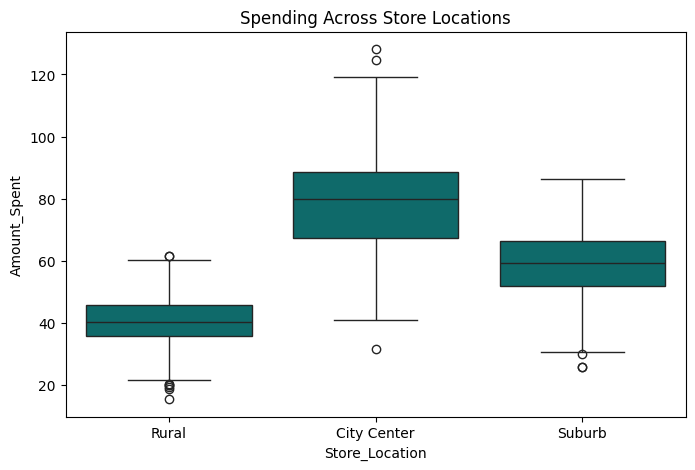

In [7]:
# Visualize data - Create new cells as needed
# Spending across locations
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Store_Location', y='Amount_Spent', color='#007979')
plt.title('Spending Across Store Locations')
plt.show()

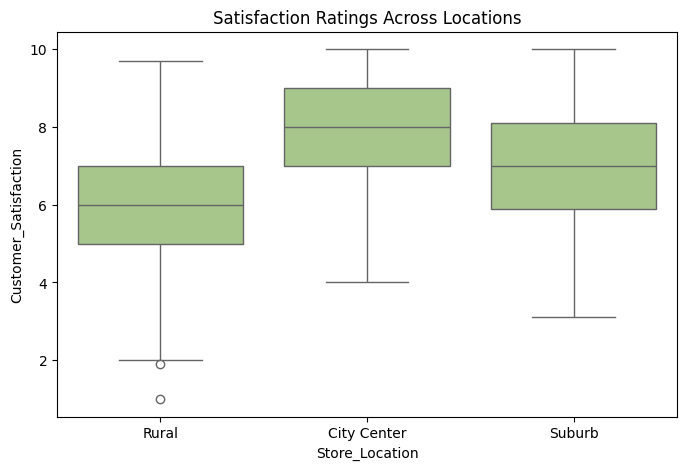

In [8]:
# Satisfaction ratings distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Store_Location', y='Customer_Satisfaction', color='#A5CF83')
plt.title('Satisfaction Ratings Across Locations')
plt.show()

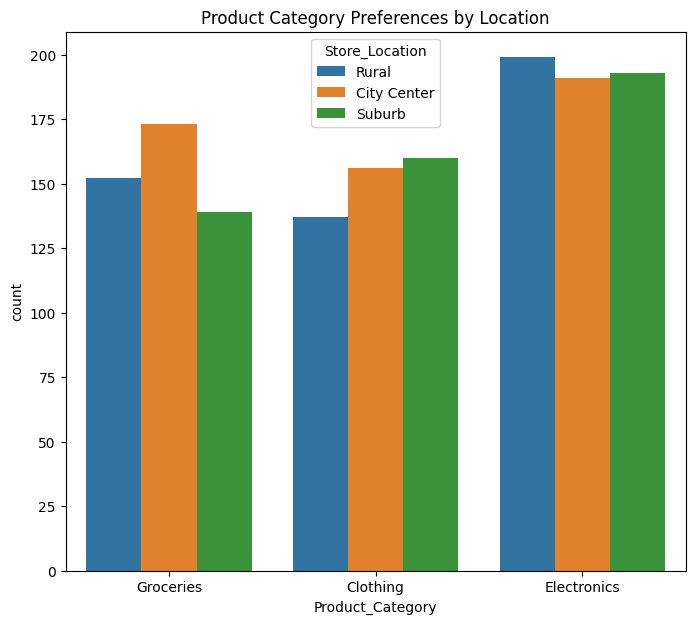

In [18]:
# Product category preferences
plt.figure(figsize=(8, 7))
sns.countplot(data=df, x='Product_Category', hue='Store_Location')
plt.title('Product Category Preferences by Location')
plt.show()

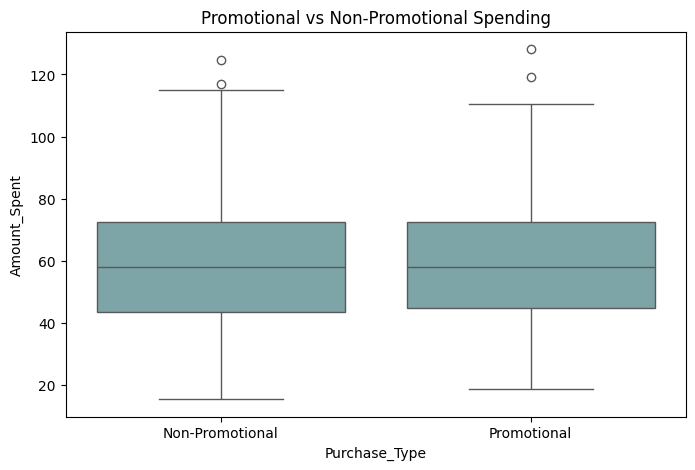

In [9]:
# Promotional vs non-promotional spending
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', color='#76ABAE')
plt.title('Promotional vs Non-Promotional Spending')
plt.show()

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

In [10]:
# Assumption tests and checks - Create new cells as needed
# Check normality for Amount_Spent per location
for location in df['Store_Location'].unique():
    data = df[df['Store_Location'] == location]['Amount_Spent']
    stat, p = stats.shapiro(data)
    print(f"{location}: p-value = {p:.4f}")

Rural: p-value = 0.2594
City Center: p-value = 0.7536
Suburb: p-value = 0.0503


In [11]:
# Check normality for Customer_Satisfaction per location
for location in df['Store_Location'].unique():
    data = df[df['Store_Location'] == location]['Customer_Satisfaction']
    stat, p = stats.shapiro(data)
    print(f"{location}: p-value = {p:.4f}")

Rural: p-value = 0.3730
City Center: p-value = 0.0000
Suburb: p-value = 0.0009


In [12]:
# Check homogeneity of variance for Amount_Spent
city = df[df['Store_Location'] == 'City Center']['Amount_Spent']
rural = df[df['Store_Location'] == 'Rural']['Amount_Spent']
suburb = df[df['Store_Location'] == 'Suburb']['Amount_Spent']

stat, p = stats.levene(city, rural, suburb)
print(f"Levene's test p-value: {p:.4f}")

Levene's test p-value: 0.0000


In [13]:
# Check normality for promotional vs non-promotional
for ptype in df['Purchase_Type'].unique():
    data = df[df['Purchase_Type'] == ptype]['Amount_Spent']
    stat, p = stats.shapiro(data)
    print(f"{ptype}: p-value = {p:.4f}")

Non-Promotional: p-value = 0.0000
Promotional: p-value = 0.0000


#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

[Write your answer here]

1. Spending across store locations -I used Kruskal-Wallis because Levene's test showed that the variances across the three locations were not equal, so ANOVA wasn't appropriate here
2.  Customer satisfaction across locations -I also used Kruskal-Wallis because the Shapiro-Wilk test showed that City Center and Suburb satisfaction data was not normally distributed
3.  Promotional vs non-promotional spending -I used Mann-Whitney U because we are only comparing two groups and the data didn't fully meet parametric assumptions
4. Product category preferences across locations - I used Chi-Square because both variables here are categorical we're just checking if product preferences depend on location 

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [14]:
# Conduct your analysis of spending patterns here
# Kruskal-Wallis test for spending across locations
city = df[df['Store_Location'] == 'City Center']['Amount_Spent']
rural = df[df['Store_Location'] == 'Rural']['Amount_Spent']
suburb = df[df['Store_Location'] == 'Suburb']['Amount_Spent']

stat, p = stats.kruskal(city, rural, suburb)
print(f"Kruskal-Wallis stat: {stat:.4f}")
print(f"p-value: {p:.4f}")

Kruskal-Wallis stat: 1040.8536
p-value: 0.0000


In [15]:
%pip install scikit-posthocs

  Obtaining dependency information for scikit-posthocs from https://files.pythonhosted.org/packages/75/50/975860099ee9f1288f030374386d110c54d58cd1dc71df023135aa79633d/scikit_posthocs-0.14.0-py3-none-any.whl.metadata
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Dunn's test to find which locations differ
import scikit_posthocs as sp

dunn_result = sp.posthoc_dunn(df, val_col='Amount_Spent', group_col='Store_Location', p_adjust='bonferroni')
print(dunn_result)

               City Center          Rural        Suburb
City Center   1.000000e+00  2.502288e-227  1.425221e-45
Rural        2.502288e-227   1.000000e+00  4.018599e-70
Suburb        1.425221e-45   4.018599e-70  1.000000e+00


Obseravtion:All p-values are basically 0.0000 which means all 3 locations are significantly different from each other

#### 3.2 Customer Satisfaction Analysis

In [18]:
# Analyze customer satisfaction here
# Kruskal-Wallis test for satisfaction across locations
city_sat = df[df['Store_Location'] == 'City Center']['Customer_Satisfaction']
rural_sat = df[df['Store_Location'] == 'Rural']['Customer_Satisfaction']
suburb_sat = df[df['Store_Location'] == 'Suburb']['Customer_Satisfaction']

stat, p = stats.kruskal(city_sat, rural_sat, suburb_sat)
print(f"Kruskal-Wallis stat: {stat:.4f}")
print(f"p-value: {p:.4f}")

Kruskal-Wallis stat: 359.5474
p-value: 0.0000


In [19]:
# Dunn's test for satisfaction
dunn_sat = sp.posthoc_dunn(df, val_col='Customer_Satisfaction', group_col='Store_Location', p_adjust='bonferroni')
print(dunn_sat)

              City Center         Rural        Suburb
City Center  1.000000e+00  1.076942e-79  2.509905e-20
Rural        1.076942e-79  1.000000e+00  6.562684e-21
Suburb       2.509905e-20  6.562684e-21  1.000000e+00


Observation:All are significantly different

#### 3.3 Promotional Impact Analysis

In [20]:
# Analyze the impact of promotions here
# Mann-Whitney U test for promotional vs non-promotional spending
promo = df[df['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']

stat, p = stats.mannwhitneyu(promo, non_promo, alternative='greater')
print(f"Mann-Whitney U stat: {stat:.4f}")
print(f"p-value: {p:.4f}")

Mann-Whitney U stat: 275125.0000
p-value: 0.3402


Observation:p = 0.3402 which is greater than 0.05 so we fail to reject H0 there is no significant difference in spending between promotional and non-promotional periods

#### 3.4 Product Category Analysis

In [21]:
# Analyze product category preferences here
# Chi-Square test for product category preferences across locations
contingency_table = pd.crosstab(df['Store_Location'], df['Product_Category'])
print(contingency_table)

stat, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square stat: {stat:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center            156          191        173
Rural                  137          199        152
Suburb                 160          193        139

Chi-Square stat: 4.7684
p-value: 0.3119
Degrees of freedom: 4


Observation:p = 0.3119 which is greater than 0.05 so we fail to reject H0 product category preferences are not significantly different across locations 

### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [22]:
# Calculate effect sizes - contrast with MDE
# Effect sizes for Kruskal-Wallis results
n = len(df)

# Eta squared for spending
eta_spending = 1040.8536 / (n - 1)
print(f"Eta squared (Spending): {eta_spending:.4f}")

# Eta squared for satisfaction
eta_satisfaction = 359.5474 / (n - 1)
print(f"Eta squared (Satisfaction): {eta_satisfaction:.4f}")

Eta squared (Spending): 0.6944
Eta squared (Satisfaction): 0.2399


**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

[Write your answer here]

1. Spending across locations —I rejected the null hypothesis here (p = 0.0000).The three locations are all spending differently from each other and the eta squared of 0.69 is huge it means where you shop explains about 69% of how much you spend.

2. Satisfaction across locations —Null hypothesis rejected again (p = 0.0000).Customers in different locations are rating their experience differently.The eta squared of 0.24 shows this is a moderate effect noticeable but not as strong as spending.

3. Promotional spending —I failed to reject the null hypothesis (p = 0.3402).Promotional periods are not actually driving customers to spend more, which raises questions about whether the promotions are worth running at all.

4. Product category preferences —Also failed to reject the hypothesis (p = 0.3119).Whether a customer is in City Center,Suburb or Rural,they tend to buy the same types of products. Location doesn't seem to influence what people buy.

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

[Write your answer here]

1. On spending —Since location has such a huge impact on how much customers spend, the company should look into why City Center customers spend more than Rural and Suburb customers. It could be due to income levels, store size or product availability. Investing more in the higher spending locations makes sense for revenue,but the company could also work on strategies to boost spending in Rural stores.
2. On satisfaction —Customer satisfaction varies across locations which means the experience is not consistent.The company should look into what is making some locations perform better than others and try to replicate that across all stores.Even small improvements in satisfaction can lead to more loyal customers.
3. On promotions —The data showed that promotions are not leading to higher spending,which is concerning.The company should rethink its promotional strategy.Maybe the promotions are not attractive enough or customers are not aware of them.It might be worth testing different types of promotions to see what actually drives spending.
4. On product preferences —Since customers across all locations buy similar products, the company does not need to stock differently per location. One consistent inventory strategy should work fine across all stores.


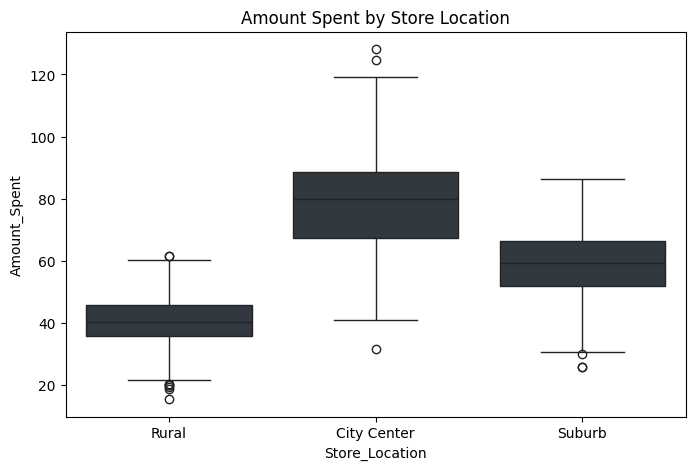

In [24]:
# Create visualizations to support results - Create new cells as needed
#Spending by location
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Store_Location', y='Amount_Spent', color='#303841')
plt.title('Amount Spent by Store Location')
plt.show()

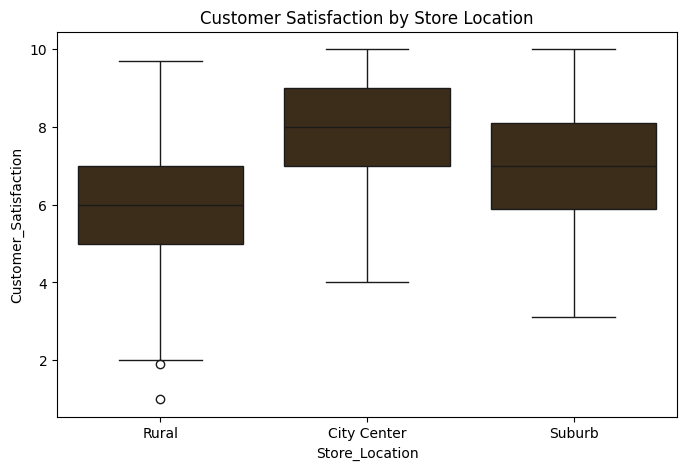

In [26]:
#Satisfaction by location
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Store_Location', y='Customer_Satisfaction', color='#412D15')
plt.title('Customer Satisfaction by Store Location')
plt.show()

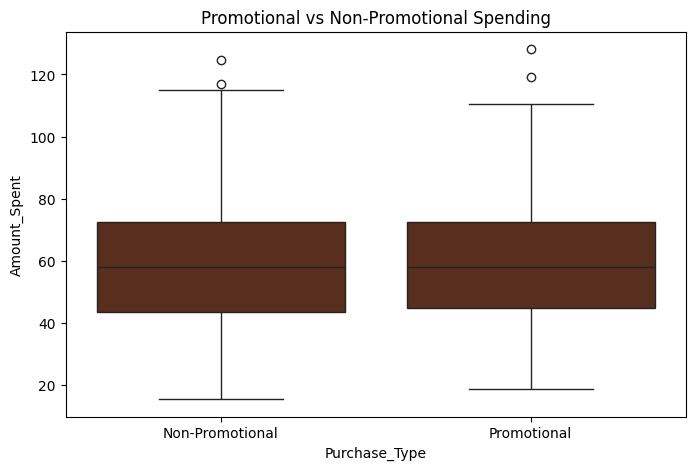

In [28]:
# Promotional spending
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', color='#622B14')
plt.title('Promotional vs Non-Promotional Spending')
plt.show()

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

[Write your reflection here]

The biggest thing I took away from this is that the planning stage matters just as much as the actual analysis. I used to think you just load data and start testing but checking assumptions first completely changed which tests I ended up using. If I had just gone straight to ANOVA I would have gotten wrong results.

Something that stood out to me was the promotions findings.I expected promotions to drive higher spending that just seems logical.But the data said otherwise and that was a good reminder that assumptions can be wrong and data doesn't always confirm what you think.

In terms of limitations,this dataset only has four variables which is quite narrow.Real customer behavior is affected by so many things like age, income,season or even how long someone has been a customer.Without that context some of our findings are hard to fully explain.

I also think 1500 rows is okay but more data would help,especially since Suburb's normality p-value was 0.0503 basically on the edge. More data would make results like that more reliable.

If I were to improve this in the future I would suggest the company collects customer demographics,tracks purchases over time and records how customers heard about promotions.That would make the analysis much stronger.

In [ ]:
%pip install scikit-posthocs

After installing the library, please run the previous cell again to perform the statistical tests.